### Required Codio Assignment 22.3: Using a Pretrained Network

**Expected Time = 90 minutes**

**Total Points = 50**

This activity introduces the use of a pretrained network with `keras`.  There are many available models, but you will use one that can be fit with smaller image examples.  To do so, you will use the `EfficientNetV2B0` model with the `cifar10` dataset from `keras`.  

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)

Run the code cell below to import the necessary libraries.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#### Information on the Model and Dataset

For more information on the model you can consult the paper from its origin [here](https://arxiv.org/abs/1905.11946) and the `keras` documentation on the model [here](https://keras.io/api/applications/efficientnet/).  For your purposes, keep in mind that this model has been trained on 1000 image classes and you will use the resulting feature maps to transform the `cifar10` data.

**The Data**

This dataset contains 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories.

The categories are:

|Label	|Description|
| ------ | ------- |
|0	|airplane|
|1	|automobile|
|2	|bird|
|3	|cat|
|4	|deer|
|5	|dog|
|6	|frog|
|7	|horse|
|8	|ship|
|9	|truck|

[Back to top](#-Index)

### Problem 1

#### Dowloading the model

**10 Points**

Below, use the `EfficientNetV2B0` function with the appropriate  `input_shape` and the argument `include_top` equal to `False` to load the base model. Assign your result to the variable `base_model`.


In [3]:
### GRADED
tf.random.set_seed(42)
base_model = ''
# YOUR CODE HERE
base_model=EfficientNetV2B0(input_shape=(32,32,3), include_top=False)# load the pre trained base model EfficientNetV2B0

### ANSWER CHECK
print(base_model)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<Functional name=efficientnetv2-b0, built=True>


[Back to top](#-Index)

### Problem 2

#### Loading and Preparing the Data

**10 Points**

In the code cell below, use the function `load_data()` on `cifar10` to prepare the target variables. Assign the result to `(X_train`, `Y_train), (X_test, Y_test)`.

Next, use the function `to_categorical` with argument `Y_train` and assign the result to `Y_train`.

Finally, use the function `to_categorical` with argument `Y_test` and assign the result to `Y_test`.



In [4]:
from tensorflow.keras.datasets import cifar10

In [5]:
### GRADED
#(X_train, Y_train), (X_test, Y_test) = ('', ''), ('', '')
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()
# YOUR CODE HERE
Y_train=to_categorical(Y_train)
Y_test = to_categorical(Y_test)

### ANSWER CHECK
print(X_train.shape)
print(Y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1474s 9us/step
(50000, 32, 32, 3)
(50000, 10)


[Back to top](#-Index)

### Problem 3

#### Generating Feature Maps

**10 Points**

To use the pretrained network, use the `.predict` method with argument equal to `X_train_sample` on `base_model`. Assign the results as `features`.  


In [6]:
#for speeding up the process
X_train_sample = X_train[:10]
y_train_sample = Y_train[:10]

In [7]:
### GRADED
tf.random.set_seed(42)
features = ''
# YOUR CODE HERE
features =base_model.predict(X_train_sample)

### ANSWER CHECK
print(features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
(10, 1, 1, 1280)


[Back to top](#-Index)

### Problem 4

#### Making Predictions for Data

**10 Points**

Below, use the function `Sequential` to create a neural network named `top` using the following architecture:

- One `Flatten` layer to flatten the results of pooling
- One `Dense` layer with 100 nodes and `relu` activation
- One `Dense` output layer 10 noded and with `softmax` activation

Compile `top` using `categorical_crossentropy` as your loss and  `accuracy` as your metric.

Use the `fit()` function on the `top` network to fit the training data `features` and `Y_train`. Set the argument `validation_split` equal to `0.2`, the argument `epochs` equal to 5, and the argument `verbose` equal to 0.  Assign the result to the variable `history` below.


In [11]:
### GRADED
tf.random.set_seed(42)
top = ''
history = ''
# YOUR CODE HERE
top = keras.Sequential([
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])
top.compile(metrics=["accuracy"], loss= "categorical_crossentropy")
history=top.fit(features, Y_train, validation_split =0.2, epochs=5, verbose=1)

### ANSWER CHECK
print(history.history['accuracy'][-5:])
print(history.history['val_accuracy'][-5:])

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2500 - loss: 2.2762 - val_accuracy: 0.0000e+00 - val_loss: 3.2030
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6250 - loss: 1.5129 - val_accuracy: 0.0000e+00 - val_loss: 3.6007
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8750 - loss: 1.1246 - val_accuracy: 0.0000e+00 - val_loss: 3.9731
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8750 - loss: 0.9149 - val_accuracy: 0.0000e+00 - val_loss: 4.0949
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.7671 - val_accuracy: 0.0000e+00 - val_loss: 4.2861
[0.25, 0.625, 0.875, 0.875, 1.0]
[0.0, 0.0, 0.0, 0.0, 0.0]


[Back to top](#-Index)

### Problem 5

#### Predicting Test Data

**10 Points**

To make predictions, use the function `predict()` on `base_model` with argument `X_test[:10]`. Assign the result to `test_features`.

Next, use the function `predict()` on the `top` object with argument equal to `test_features`. Use the function NumPy  function `argmax` to retrieve the indices of the maximum elements in the array along the `axis` 1.
Assign the result to the variable `preds`.

HINT: The pseudocode for this last step is given below:

```Python
preds = np.argmax(conv_model.predict(...), axis = ...)
```

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


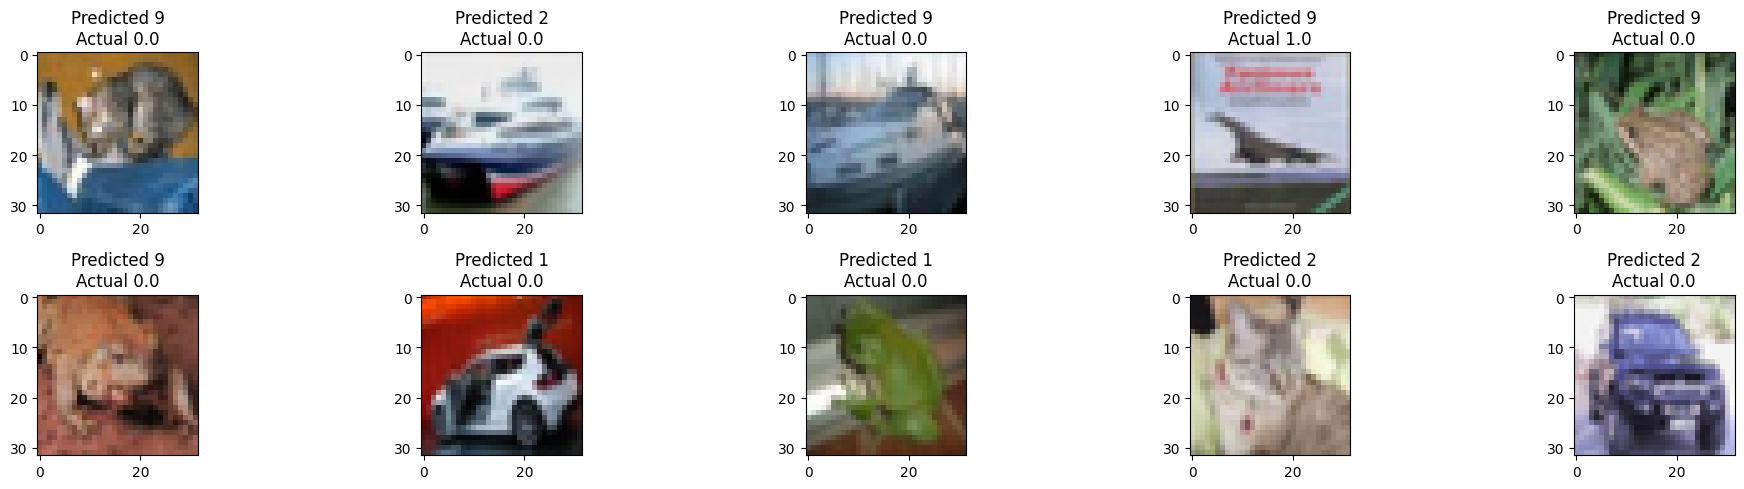

In [30]:
### GRADED
tf.random.set_seed(42)
test_exs = X_test[:10]
test_preds = ''
# YOUR CODE HERE
test_features = base_model.predict(X_test[:10])
preds = np.argmax(top.predict(test_features),axis =1 )

### ANSWER CHECK
print(test_preds)
print(Y_test[:10].reshape(10,10))
fig, ax = plt.subplots(2, 5, figsize = (20, 5))
c = 0
for i in range(2):
    for j in range(5):
        ax[i, j].imshow(X_test[c])
        ax[i, j].set_title(f'Predicted {preds[c]}\nActual {Y_test[c][0]}')
        c += 1
plt.tight_layout()

In [27]:
Y_test[:10].reshape(10,10)

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])